In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
data = pd.read_csv("/content/Nat_Gas.csv")
data.head(10)

,Dates,Prices
0,10/31/20,10.10
1,11/30/20,10.30
2,12/31/20,11.00
3,1/31/21,10.90
4,2/28/21,10.90
5,3/31/21,10.90
6,4/30/21,10.40
7,5/31/21,9.84
8,6/30/21,10.00
9,7/31/21,10.10


# Preparing Data

In [ ]:
data["Dates"] = pd.to_datetime(data["Dates"])

/tmp/ipykernel_2033/1637646221.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Dates"] = pd.to_datetime(data["Dates"])


In [ ]:
data["year"] = data.Dates.dt.year
data["month"] = data.Dates.dt.month
data = data.drop(["Dates"],axis=1)
data.head(10)

,Prices,year,month
0,10.10,2020,10
1,10.30,2020,11
2,11.00,2020,12
3,10.90,2021,1
4,10.90,2021,2
5,10.90,2021,3
6,10.40,2021,4
7,9.84,2021,5
8,10.00,2021,6
9,10.10,2021,7


In [ ]:
data.year.value_counts()

,count
year,
2021,12
2023,12
2022,12
2024,9
2020,3


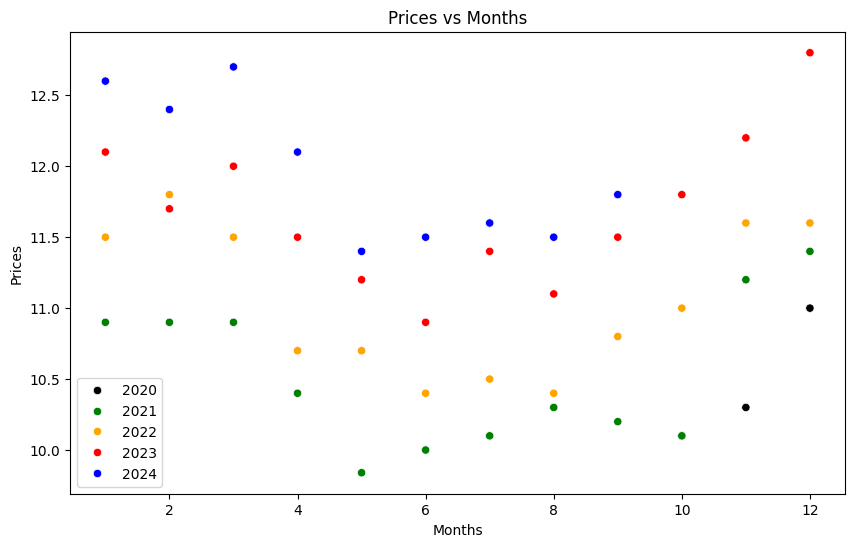

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=data, x="month", y="Prices", hue="year", palette={2024:"Blue",2023:"Red",2022:"Orange",2021:"Green",2020:"Black"})
plt.xlabel("Months")
plt.ylabel("Prices")
plt.title("Prices vs Months")
plt.legend()
plt.show()

In [ ]:
def sin_cos(month):
  sin = np.sin(2*np.pi*month/12)
  cos = np.cos(2*np.pi*month/12)
  return [sin, cos]


In [ ]:
def year(yer):
  year = yer[2:]
  return int(year)

In [ ]:
data["sin_month"] = data["month"].map(lambda x: sin_cos(x)[0])
data["cos_month"] = data["month"].map(lambda x: sin_cos(x)[1])
data["year"] = data["year"].map(lambda x: year(str(x)))

In [ ]:
data = data.drop(["month"],axis=1)

In [ ]:
data.head(10)

,Prices,year,sin_month,cos_month
0,10.10,20,-8.660254e-01,5.000000e-01
1,10.30,20,-5.000000e-01,8.660254e-01
2,11.00,20,-2.449294e-16,1.000000e+00
3,10.90,21,5.000000e-01,8.660254e-01
4,10.90,21,8.660254e-01,5.000000e-01
5,10.90,21,1.000000e+00,6.123234e-17
6,10.40,21,8.660254e-01,-5.000000e-01
7,9.84,21,5.000000e-01,-8.660254e-01
8,10.00,21,1.224647e-16,-1.000000e+00
9,10.10,21,-5.000000e-01,-8.660254e-01


# Regression Model

In [ ]:
X = data.drop(["Prices"],axis=1)
y = data["Prices"]

In [ ]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
lr = LinearRegression()
lr.fit(X_poly,y)
y_pred = lr.predict(X_poly)

In [ ]:
print(r2_score(y,y_pred))
print(mean_squared_error(y,y_pred))


0.9141238034125863
0.048300336226557376


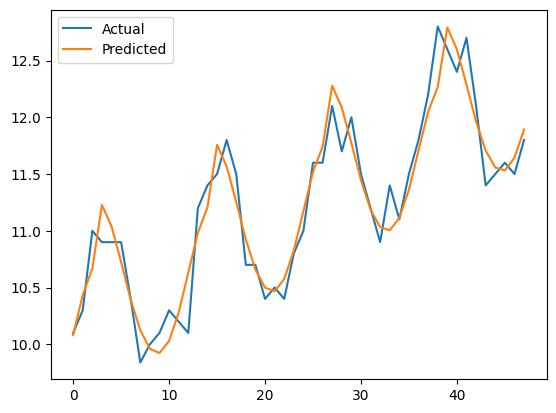

In [ ]:
plt.plot(y, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.show()

# Extrapolation Data

In [ ]:
Last_known_date = [24,9]
def add_year(kd):
  x= kd[0]
  y= kd[1]
  yr = []
  for i in range(1,12):
    if y==12:
      x += 1
      y = 1
      yr.append([x,y])
    else:
      y += 1
      yr.append([x,y])
  return yr


In [ ]:
ylist = add_year(Last_known_date)
ylist

[[24, 10],
 [24, 11],
 [24, 12],
 [25, 1],
 [25, 2],
 [25, 3],
 [25, 4],
 [25, 5],
 [25, 6],
 [25, 7],
 [25, 8]]

In [ ]:
fudf = pd.DataFrame(ylist, columns=["year","month"])
fudf["sin_month"] = fudf["month"].map(lambda x: sin_cos(x)[0])
fudf["cos_month"] = fudf["month"].map(lambda x: sin_cos(x)[1])
fudf.drop(["month"],axis=1,inplace=True)
fudf.head(10)

,year,sin_month,cos_month
0,24,-8.660254e-01,5.000000e-01
1,24,-5.000000e-01,8.660254e-01
2,24,-2.449294e-16,1.000000e+00
3,25,5.000000e-01,8.660254e-01
4,25,8.660254e-01,5.000000e-01
5,25,1.000000e+00,6.123234e-17
6,25,8.660254e-01,-5.000000e-01
7,25,5.000000e-01,-8.660254e-01
8,25,1.224647e-16,-1.000000e+00
9,25,-5.000000e-01,-8.660254e-01


# Futuar Year Estimate

In [ ]:
Xf = poly.transform(fudf)
yf = lr.predict(Xf)

In [ ]:
yf

array([12.23348708, 12.57079662, 12.78354744, 13.29705402, 13.10241097,
       12.7910717 , 12.46986787, 12.21846159, 12.07440423, 12.05288729,
       12.1660804 ])

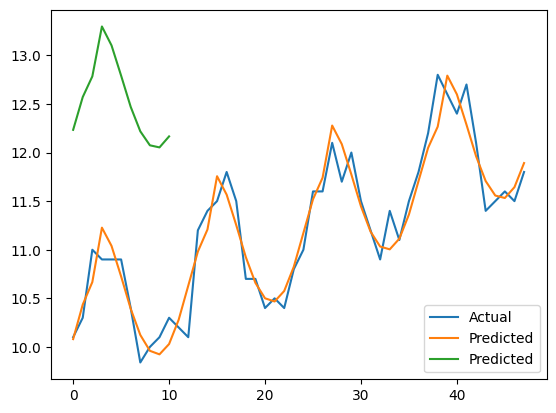

In [ ]:
plt.plot(y, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.plot(yf, label="Predicted")
plt.legend()
plt.show()

# Staking data

In [ ]:
pry = yf.reshape(-1,1)
pry

array([[12.23348708],
       [12.57079662],
       [12.78354744],
       [13.29705402],
       [13.10241097],
       [12.7910717 ],
       [12.46986787],
       [12.21846159],
       [12.07440423],
       [12.05288729],
       [12.1660804 ]])

In [ ]:
fd = fudf[["year","sin_month","cos_month"]].values
fu_data = np.hstack([pry,fudf])

In [ ]:
fudf = pd.DataFrame(fu_data, columns=["Prices","year","sin_month","cos_month"])
fudf["year"] = fudf["year"].astype(int)
fudf.head(10)

,Prices,year,sin_month,cos_month
0,12.233487,24,-8.660254e-01,5.000000e-01
1,12.570797,24,-5.000000e-01,8.660254e-01
2,12.783547,24,-2.449294e-16,1.000000e+00
3,13.297054,25,5.000000e-01,8.660254e-01
4,13.102411,25,8.660254e-01,5.000000e-01
5,12.791072,25,1.000000e+00,6.123234e-17
6,12.469868,25,8.660254e-01,-5.000000e-01
7,12.218462,25,5.000000e-01,-8.660254e-01
8,12.074404,25,1.224647e-16,-1.000000e+00
9,12.052887,25,-5.000000e-01,-8.660254e-01


In [ ]:
full_df = pd.concat([data,fudf],axis=0)
full_df.tail(10)

,Prices,year,sin_month,cos_month
1,12.570797,24,-5.000000e-01,8.660254e-01
2,12.783547,24,-2.449294e-16,1.000000e+00
3,13.297054,25,5.000000e-01,8.660254e-01
4,13.102411,25,8.660254e-01,5.000000e-01
5,12.791072,25,1.000000e+00,6.123234e-17
6,12.469868,25,8.660254e-01,-5.000000e-01
7,12.218462,25,5.000000e-01,-8.660254e-01
8,12.074404,25,1.224647e-16,-1.000000e+00
9,12.052887,25,-5.000000e-01,-8.660254e-01
10,12.166080,25,-8.660254e-01,-5.000000e-01


In [ ]:
full_df.to_csv("full_df.csv", index=False)

# Random Date Quary

In [ ]:
def random(ind):
  x = ind[0]
  y = ind[1]
  sin = sin_cos(y)[0]
  cos = sin_cos(y)[1]
  X = np.array([[x,sin,cos]])
  Xp = poly.transform(X)
  yp = lr.predict(Xp)
  return yp

In [ ]:
random([26,10])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([13.26301029])

# Saving the Model

In [ ]:
import joblib

# Save the trained model to a file
joblib.dump(lr, 'linear_regression_model.joblib')


['linear_regression_model.joblib']